# QAOA on Max-k-XOR-SAT via Symmetric Tensor Contraction

## Background

The Quantum Approximate Optimization Algorithm (QAOA) prepares a variational quantum state by alternating two operators at depth $p$:

$$|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle = \prod_{\ell=1}^{p} e^{-i \beta_\ell B} \, e^{-i \gamma_\ell C} \, |+\rangle^{\otimes N}$$

- **Phase separator** $e^{-i\gamma C}$: encodes the problem cost function $C$ (here $C = Z^{\otimes k}$ on each hyperedge)
- **Mixer** $e^{-i\beta B}$: drives exploration (here $B = \sum_i X_i$, applying $R_x(2\beta)$ to each qubit)

The QAOA energy at depth $p$ is the expectation value $\langle \boldsymbol{\gamma}, \boldsymbol{\beta} | C | \boldsymbol{\gamma}, \boldsymbol{\beta}\rangle$, optimized over the $2p$ angles $(\boldsymbol{\gamma}, \boldsymbol{\beta})$. The satisfaction fraction (fraction of satisfied clauses) is related to the expectation value by:

$$\frac{s}{m} = \frac{1 - \langle Z^{\otimes k} \rangle}{2}$$

## This Module

For Max-k-XOR-SAT on $D$-regular, $k$-uniform hypergraph trees, we exploit the tree symmetry to compute $\langle Z^{\otimes k} \rangle$ exactly via symmetric tensor contraction. The cost is $O(p \cdot 4^p)$, independent of $D$, $k$, and the light-cone size $N_{\text{lc}}$ — reducing the problem from doubly exponential (state-vector simulation) to singly exponential in $p$.

This notebook reproduces the QAOA numerical results from:

> N. Shutty, A. Mandal, S. Ragavan, Q. Buzet, A. Chailloux, N. C. Rubin, A. Khan, S. Boulebnane, R. Shaydulin, J. Azariah, S. P. Jordan, "Optimization Using Locally-Quantum Decoders," [arXiv:2604.24633](https://arxiv.org/abs/2604.24633) (2026).

**No backend compilation is required** to run the analysis sections — precomputed optimized angles are bundled with the package.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.optimize import curve_fit

from qokit.max_k_xor_sat import (
    load_precomputed_results,
    load_benchmark_energies,
    get_available_configs,
    contract_symmetric_tree,
    light_cone_size,
)

# === Configuration ===
# Backend: 'cpp' (C++, supports dd precision), 'jax' (GPU), or 'auto'
backend = "cpp"
# Precision: 'float64' (default) or 'dd' (double-double, C++ only)
precision = "float64"

# Publication-quality defaults
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 17,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.grid': True,
    'grid.alpha': 0.2,
})

## 1. Live Computation

If you have a backend installed (C++ or JAX), you can compute new values.

The `contract_symmetric_tree` function supports two precision modes:
- **`precision="float64"`** (default): standard 64-bit doubles (~15 significant digits). Works with both C++ and JAX backends. Sufficient for small branching factors (k-1)*(D-1).
- **`precision="dd"`**: double-double arithmetic (~32 significant digits). C++ backend only. Required for configurations with large branching factors $(k-1)(D-1)$ where Float64 rounding errors accumulate exponentially through the entrywise powers. This is what was used to compute the published p=16 results.

And three backend options:
- **`backend="cpp"`**: C++ backend, supports float64 and double-double precision. Best for production use: OpenMP parallelism, reverse-mode adjoint gradient.
- **`backend="jax"`**: JAX/GPU backend, float64 only. Best for GPU acceleration at moderate p. Uses `@jax.jit` compilation and forward-mode JVP for gradients.
- **`backend="auto"`** (default): tries C++ first, then JAX.

In [ ]:
# Configuration
k, D, p = 7, 8, 5

# Load optimized angles from precomputed results
data = load_precomputed_results(k, D)
entry = data["results"][str(p)]
gammas = np.array(entry["gammas"])
betas = np.array(entry["betas"])

# Or use fixed angles directly:
# gammas = np.array([0.3, 0.4, 0.5, 0.6, 0.7])
# betas = np.array([0.4, 0.35, 0.3, 0.25, 0.2])

try:
    val = contract_symmetric_tree(gammas, betas, p=p, D=D, k=k,
                                  precision=precision, backend=backend)
    N_lc = light_cone_size(p, D, k)
    print(f"k={k}, D={D}, p={p}")
    print(f"<Z^{k}> = {val:.10f}")
    print(f"Energy (satisfaction fraction) = {(1 - val) / 2:.10f}")
    print(f"Light cone size: {N_lc} qubits")
    print(f"Branching factor: a = (D-1)*(k-1) = {(D-1)*(k-1)}")
except RuntimeError as e:
    print(f"No backend available: {e}")
    print("To enable live computation, build the C++ backend:")
    print("  cd qokit/max_k_xor_sat/cpp && mkdir -p build && cd build && cmake .. && make -j")
    print("Or install JAX: pip install 'qokit[xorsat-gpu]'")

## 2. Angle Optimization

The `optimize_angles` function finds the optimal QAOA angles for a given (k, D, p) configuration. It supports three optimizers:
- **`'bobyqa'`** (default): gradient-free, with optional Chebyshev parameterization for high-p
- **`'lbfgs'`**: gradient-based via reverse-mode adjoint (~3x forward cost)
- **`'steepest'`**: FD gradient + line search, forward-only memory — for high-p DD where the adjoint doesn't fit

Angles are warm-started from precomputed results or extrapolated from lower depths via Chebyshev interpolation.

In [ ]:
from qokit.max_k_xor_sat import optimize_angles
from qokit.max_k_xor_sat.optimize.seed import scaled_extrap

# Optimize angles for k=2, D=3 at p=5
# Warm-start from optimized angles at p=2, 3, 4 using scaled extrapolation
k_opt, D_opt, p_opt = 2, 3, 5

# Load optimized angles from previous depths
data_opt = load_precomputed_results(k_opt, D_opt)
source_ps = [p_opt - 3, p_opt - 2, p_opt - 1]  # p=2, 3, 4
source_gammas = [np.array(data_opt["results"][str(p)]["gammas"]) for p in source_ps]
source_betas = [np.array(data_opt["results"][str(p)]["betas"]) for p in source_ps]

# Extrapolate to target depth using scaled linear extrapolation
# This fits per-position trends across the source depths and projects forward
seed_gammas = scaled_extrap(source_gammas, source_ps, p_opt)
seed_betas = scaled_extrap(source_betas, source_ps, p_opt)

print(f"Extrapolating from p={source_ps} -> p={p_opt}")
print(f"Seed gammas: {seed_gammas}")
print(f"Seed betas:  {seed_betas}")

# Evaluate the extrapolated (unoptimized) seed
seed_val = contract_symmetric_tree(seed_gammas, seed_betas, p=p_opt, D=D_opt, k=k_opt,
                                   backend=backend)
print(f"\nBefore optimization: s/m = {(1 - seed_val) / 2:.10f}")

# Compare to the known optimum
known_val = data_opt["results"][str(p_opt)]["objective"]
print(f"Known optimum:       s/m = {known_val:.10f}")

# optimizer options:
#   'lbfgs'    - gradient-based via reverse-mode adjoint, best for p <= 14
#   'bobyqa'   - gradient-free, use n_cheb for Chebyshev parameterization at high p (requires pybobyqa)
#   'steepest' - FD gradient + line search, forward-only memory, for high-p DD
try:
    # Provide the extrapolated seed via seed_fn
    def my_seed(k, D, p):
        return seed_gammas, seed_betas, f"scaled_extrap(p={source_ps})"

    result = optimize_angles(k=k_opt, D=D_opt, p=p_opt, maxiter=50,
                             optimizer="lbfgs", backend=backend,
                             seed_fn=my_seed, verbose=True)
    print(f"\nAfter optimization:")
    print(f"  gammas = {result['gammas']}")
    print(f"  betas  = {result['betas']}")
    print(f"  <Z^{k_opt}>  = {result['expectation']:.10f}")
    print(f"  s/m    = {result['objective']:.10f}")
    print(f"  evals  = {result['num_evals']}")
    print(f"  seed   = {result['seed_source']}")
except (RuntimeError, ImportError) as e:
    print(f"Optimizer not available: {e}")
    print("Install with: pip install 'qokit[xorsat-optimize]'")

## 3. Load All Precomputed Results

We have optimized QAOA energies for 16 $(k, D)$ configurations at depths $p = 1, \ldots, 16$.

In [4]:
# Load all available configurations
configs = get_available_configs()
print(f"Available configurations: {len(configs)}")

all_datasets = []
for k, D in configs:
    data = load_precomputed_results(k, D)
    results = data["results"]
    p_vals = sorted(int(p) for p in results)
    energies = [results[str(p)]["objective"] for p in p_vals]
    gammas = [np.array(results[str(p)]["gammas"]) for p in p_vals]
    betas = [np.array(results[str(p)]["betas"]) for p in p_vals]
    all_datasets.append({
        "k": k, "D": D,
        "p": np.array(p_vals),
        "energy": np.array(energies),
        "gammas": gammas,
        "betas": betas,
    })

all_datasets.sort(key=lambda ds: (ds["k"], ds["D"]))

# Load benchmark energies from classical algorithms
bench_data = load_benchmark_energies()
bench_columns = bench_data["columns"]
benchmarks = bench_data["data"]
print(f"Benchmark algorithms: {bench_columns}")
print(f"\nConfigurations:")
for ds in all_datasets:
    print(f"  k={ds['k']}, D={ds['D']}: p=1..{ds['p'][-1]} "
          f"(best energy = {ds['energy'].max():.4f})")

Available configurations: 16
Benchmark algorithms: ['Prange', 'Simulated Annealing', 'DQI+BP', 'Regev+FGUM']

Configurations:
  k=2, D=3: p=1..16 (best energy = 0.8955)
  k=3, D=4: p=1..16 (best energy = 0.8898)
  k=3, D=5: p=1..16 (best energy = 0.8532)
  k=3, D=6: p=1..16 (best energy = 0.8231)
  k=3, D=7: p=1..16 (best energy = 0.8001)
  k=3, D=8: p=1..16 (best energy = 0.7813)
  k=4, D=5: p=1..16 (best energy = 0.8797)
  k=4, D=6: p=1..16 (best energy = 0.8498)
  k=4, D=7: p=1..16 (best energy = 0.8259)
  k=4, D=8: p=1..16 (best energy = 0.8061)
  k=5, D=6: p=1..16 (best energy = 0.8669)
  k=5, D=7: p=1..16 (best energy = 0.8428)
  k=5, D=8: p=1..15 (best energy = 0.8200)
  k=6, D=7: p=1..15 (best energy = 0.8520)
  k=6, D=8: p=1..16 (best energy = 0.8343)
  k=7, D=8: p=1..16 (best energy = 0.8431)


## 4. Full Comparison Table: QAOA vs Classical Algorithms

Satisfaction fraction $s/m$ for all $(k, D)$ configurations at the maximum computed depth.

In [5]:
# Build comparison table (k>=3 only, as presented in the paper)
max_p = max(ds["p"][-1] for ds in all_datasets)

print(f"{'(k,D)':>7} | {'Prange':>8} | {'Sim.Ann.':>8} | {'DQI+BP':>8} | "
      f"{'Regev+FGUM':>10} | {'QAOA(p='+str(max_p)+')':>12}")
print("-" * 72)

for ds in all_datasets:
    if ds['k'] == 2 and ds['D'] == 3:
        continue  # skip MaxCut case
    key = f"{ds['k']},{ds['D']}"
    bv = benchmarks.get(key, [0, 0, 0, 0])
    qaoa_best = ds["energy"].max()
    best_classical = max(bv)
    marker = "*" if qaoa_best > best_classical else " "
    print(f"({ds['k']},{ds['D']}){' '*(4-len(key))} | "
          f"{bv[0]:>8.4f} | {bv[1]:>8.4f} | {bv[2]:>8.4f} | "
          f"{bv[3]:>10.4f} | {qaoa_best:>11.4f}{marker}")

  (k,D) |   Prange | Sim.Ann. |   DQI+BP | Regev+FGUM |   QAOA(p=16)
------------------------------------------------------------------------
(3,4)  |   0.8750 |   0.9366 |   0.8707 |     0.8919 |      0.8898 
(3,5)  |   0.8000 |   0.9005 |   0.8165 |     0.8361 |      0.8532 
(3,6)  |   0.7500 |   0.8712 |   0.7756 |     0.7836 |      0.8231 
(3,7)  |   0.7143 |   0.8492 |   0.7473 |     0.7602 |      0.8001 
(3,8)  |   0.6875 |   0.8287 |   0.7235 |     0.7294 |      0.7813 
(4,5)  |   0.9000 |   0.9279 |   0.8597 |     0.9216 |      0.8797 
(4,6)  |   0.8333 |   0.9024 |   0.8206 |     0.8614 |      0.8498 
(4,7)  |   0.7857 |   0.8771 |   0.7886 |     0.8265 |      0.8259 
(4,8)  |   0.7500 |   0.8587 |   0.7654 |     0.7902 |      0.8061 
(5,6)  |   0.9167 |   0.9190 |   0.8430 |     0.9312 |      0.8669 
(5,7)  |   0.8571 |   0.8965 |   0.8142 |     0.8853 |      0.8428 
(5,8)  |   0.8125 |   0.8740 |   0.7875 |     0.8440 |      0.8200 
(6,7)  |   0.9286 |   0.9051 |   0.8276 | 

## 5. All Configurations: Energy vs Depth

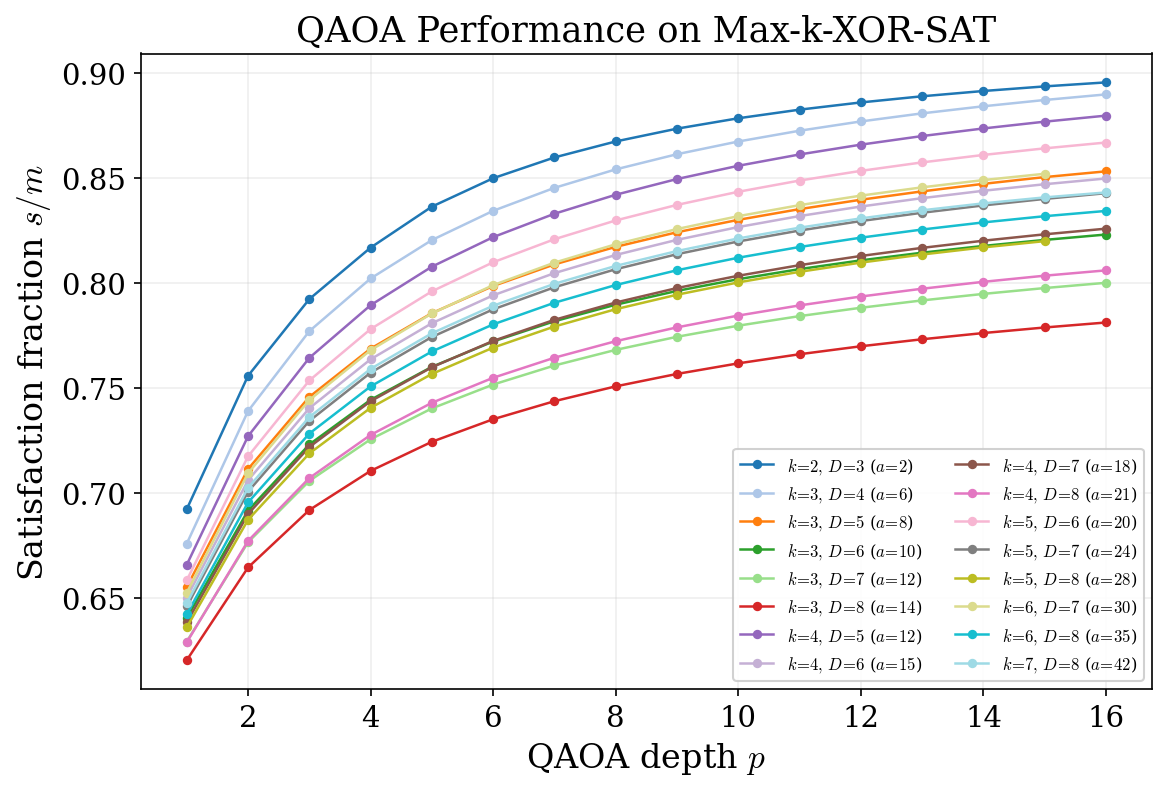

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))

cmap = plt.cm.tab20
for i, ds in enumerate(all_datasets):
    color = cmap(i / max(len(all_datasets) - 1, 1))
    a = (ds['D'] - 1) * (ds['k'] - 1)
    ax.plot(ds["p"], ds["energy"], "o-", color=color, markersize=3.5,
            linewidth=1.2, label=rf"$k\!=\!{ds['k']},\,D\!=\!{ds['D']}$ ($a\!=\!{a}$)")

ax.set_xlabel(r"QAOA depth $p$")
ax.set_ylabel(r"Satisfaction fraction $s/m$")
ax.set_title("QAOA Performance on Max-k-XOR-SAT")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(fontsize=8, ncol=2, loc="lower right", framealpha=0.9)
fig.tight_layout()
plt.show()

## 6. Deep Dive: $k=3$, $D=5$

Energy curve with power-law fit, comparison to classical benchmarks, and crossover prediction.

Fit: E_inf = 0.919319, c = 0.5014, b = 1.4761, alpha = 0.7078


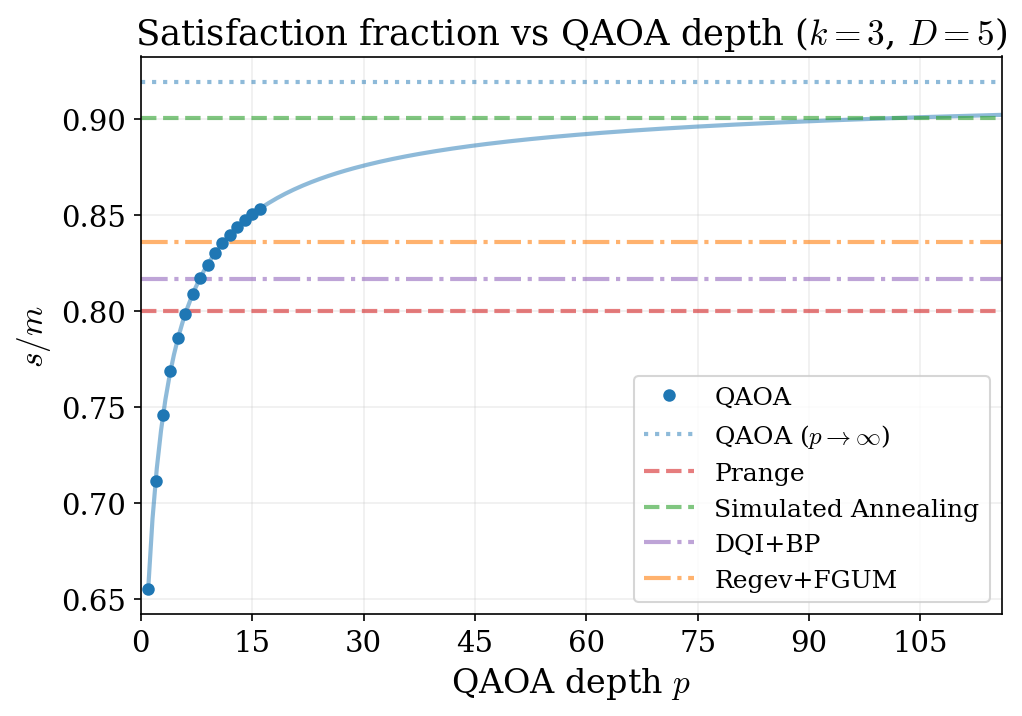


Predicted crossover depth (QAOA > best classical): p_beat ~ 102


In [7]:
# Select k=3, D=5 dataset
ds = next(d for d in all_datasets if d["k"] == 3 and d["D"] == 5)

# Fit E(p) = E_inf - c / (p + b)^alpha
def energy_model(p, E_inf, c, b, alpha):
    return E_inf - c / (p + b) ** alpha

p0 = [ds["energy"][-1] + 0.05, 0.5, 1.0, 1.0]
bounds = ([ds["energy"][-1], 0, 0, 0.01], [1.0, 50.0, 50.0, 10.0])
popt, pcov = curve_fit(energy_model, ds["p"].astype(float), ds["energy"],
                       p0=p0, bounds=bounds, maxfev=50000)
E_inf, c_fit, b_fit, alpha_fit = popt
print(f"Fit: E_inf = {E_inf:.6f}, c = {c_fit:.4f}, b = {b_fit:.4f}, alpha = {alpha_fit:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(ds["p"], ds["energy"], 'o', color='#1f77b4', markersize=5,
        zorder=5, label="QAOA")

# Fit curve extrapolated
p_fit = np.linspace(ds["p"].min(), ds["p"].max() + 100, 200)
ax.plot(p_fit, energy_model(p_fit, *popt), "-", color="#1f77b4",
        alpha=0.5, linewidth=2)
ax.axhline(E_inf, color="#1f77b4", linestyle=":", alpha=0.5,
           linewidth=2, label=r"QAOA ($p\to\infty$)")

# Benchmarks
bench_key = f"{ds['k']},{ds['D']}"
bench_styles = [
    {"color": "#d62728", "linestyle": "--", "linewidth": 2},
    {"color": "#2ca02c", "linestyle": "--", "linewidth": 2},
    {"color": "#9467bd", "linestyle": "-.", "linewidth": 2},
    {"color": "#ff7f0e", "linestyle": "-.", "linewidth": 2},
]
if bench_key in benchmarks:
    bv = benchmarks[bench_key]
    for i, (name, val) in enumerate(zip(bench_columns, bv)):
        ax.axhline(val, label=name, alpha=0.6, **bench_styles[i])

ax.set_xlabel(r"QAOA depth $p$")
ax.set_ylabel(r"$s/m$")
ax.set_title(rf"Satisfaction fraction vs QAOA depth ($k={ds['k']}$, $D={ds['D']}$)")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(loc='lower right', fontsize=12)
ax.set_xlim(0, ds["p"].max() + 100)
fig.tight_layout()
plt.show()

# Crossover prediction
best_classical = max(benchmarks[bench_key])
if E_inf > best_classical:
    ratio = c_fit / (E_inf - best_classical)
    p_cross = ratio ** (1.0 / alpha_fit) - b_fit
    print(f"\nPredicted crossover depth (QAOA > best classical): p_beat ~ {int(np.ceil(p_cross))}")
else:
    print(f"\nExtrapolation predicts QAOA will not surpass best classical ({best_classical:.4f})")

## 7. Angle Profiles

Optimized $\gamma_i$ and $\beta_i$ plotted against normalized position, colored by depth $p$.

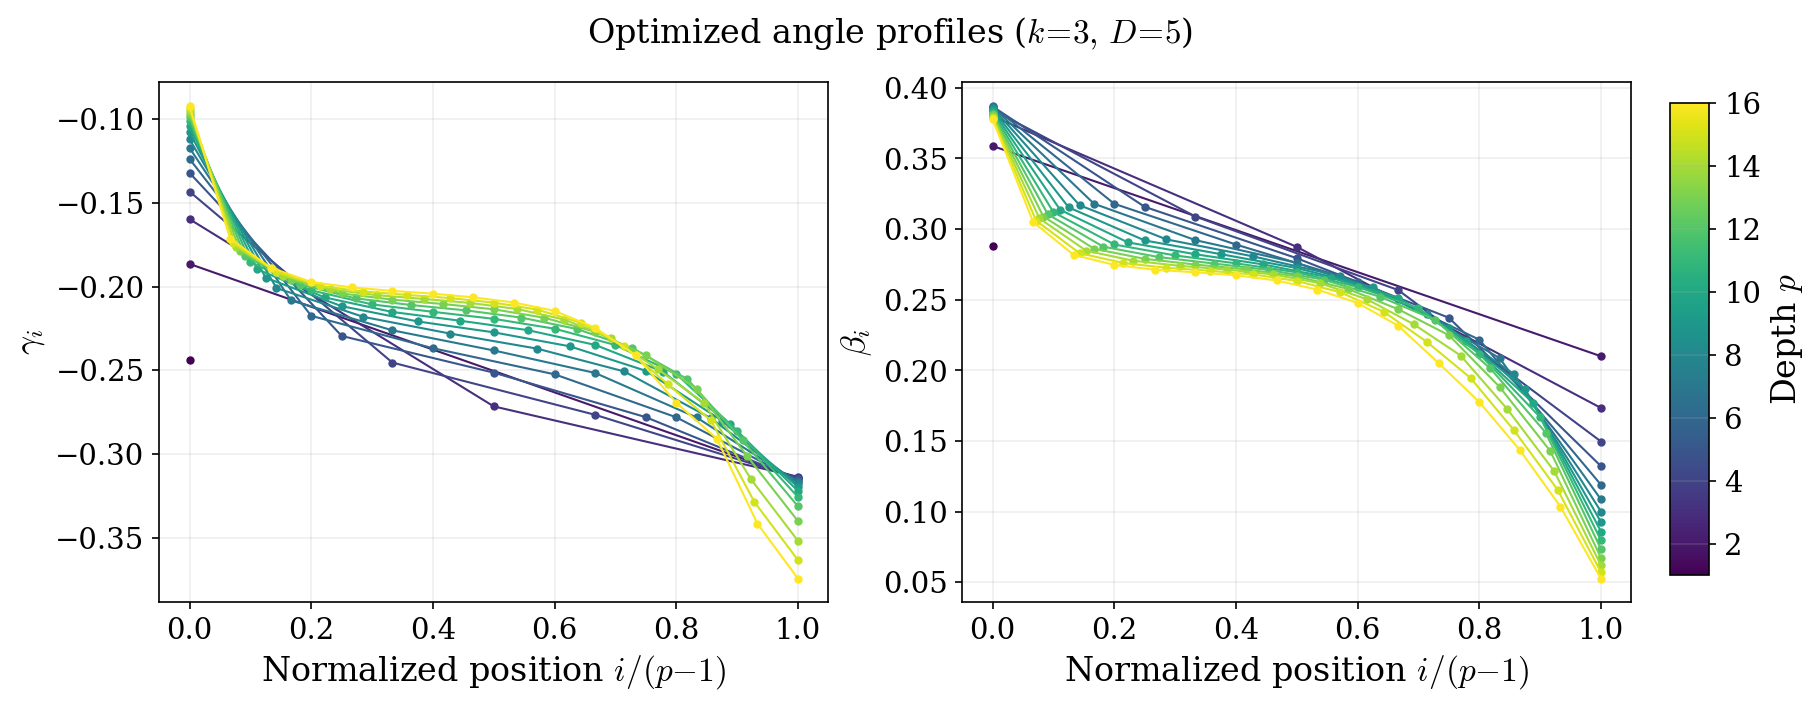

In [8]:
fig, (ax_g, ax_b) = plt.subplots(1, 2, figsize=(13, 4.5))

cmap = plt.cm.viridis
p_vals = ds["p"]
norm = plt.Normalize(p_vals.min(), p_vals.max())

for p, gammas, betas in zip(p_vals, ds["gammas"], ds["betas"]):
    t = np.linspace(0, 1, p)
    color = cmap(norm(p))
    ax_g.plot(t, gammas, "o-", color=color, markersize=3, linewidth=1)
    ax_b.plot(t, betas, "o-", color=color, markersize=3, linewidth=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

for ax, label in [(ax_g, r"$\gamma_i$"), (ax_b, r"$\beta_i$")]:
    ax.set_xlabel(r"Normalized position $i/(p{-}1)$")
    ax.set_ylabel(label)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r"Depth $p$")

fig.suptitle(rf"Optimized angle profiles ($k\!=\!{ds['k']},\, D\!=\!{ds['D']}$)",
             fontsize=16)
plt.show()

## 8. Extrapolation Analysis

Fit $E(p) = E_\infty - c/(p+b)^\alpha$ with bootstrap confidence intervals.

k=3, D=5:
  E_inf = 0.919319
  95% CI = [0.917017, 0.930012]
  Bootstrap std = 0.003735
  Successful fits: 2000/2000


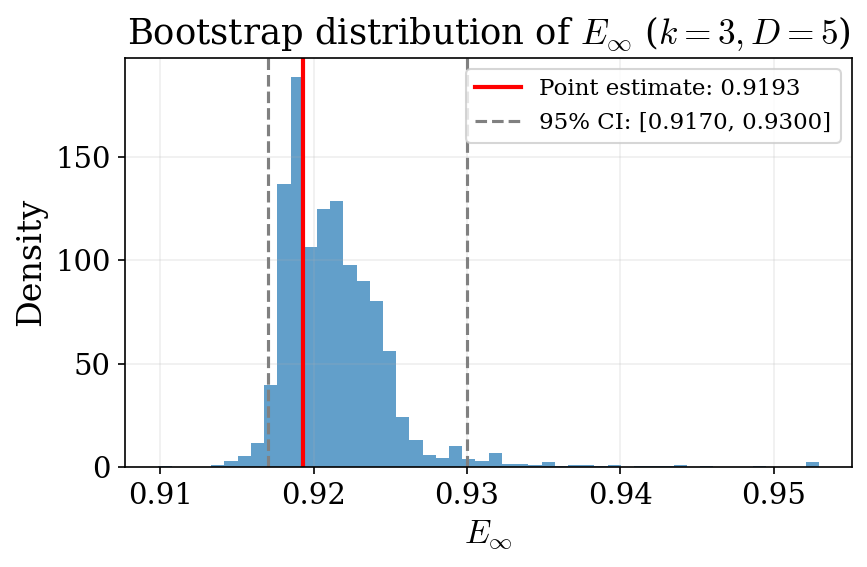

In [9]:
# Bootstrap CI for E_inf
rng = np.random.default_rng(42)
n_boot = 2000
boot_Einfs = []

n = len(ds["p"])
for _ in range(n_boot):
    idx = rng.integers(0, n, size=n)
    p_boot = ds["p"][idx].astype(float)
    e_boot = ds["energy"][idx]
    try:
        bp, _ = curve_fit(energy_model, p_boot, e_boot, p0=popt,
                          bounds=([e_boot.min(), 0, 0, 0.01], [1.0, 50.0, 50.0, 10.0]),
                          maxfev=50000)
        boot_Einfs.append(bp[0])
    except (RuntimeError, ValueError):
        pass

boot_Einfs = np.array(boot_Einfs)
ci_lo, ci_hi = np.percentile(boot_Einfs, [2.5, 97.5])

print(f"k={ds['k']}, D={ds['D']}:")
print(f"  E_inf = {E_inf:.6f}")
print(f"  95% CI = [{ci_lo:.6f}, {ci_hi:.6f}]")
print(f"  Bootstrap std = {boot_Einfs.std():.6f}")
print(f"  Successful fits: {len(boot_Einfs)}/{n_boot}")

# Histogram
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(boot_Einfs, bins=50, density=True, alpha=0.7, color='#1f77b4')
ax.axvline(E_inf, color='red', linewidth=2, label=f'Point estimate: {E_inf:.4f}')
ax.axvline(ci_lo, color='gray', linestyle='--', label=f'95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]')
ax.axvline(ci_hi, color='gray', linestyle='--')
ax.set_xlabel(r'$E_\infty$')
ax.set_ylabel('Density')
ax.set_title(rf'Bootstrap distribution of $E_\infty$ ($k={ds["k"]}, D={ds["D"]}$)')
ax.legend()
fig.tight_layout()
plt.show()